In [2]:
from statsmodels.regression.rolling import RollingOLS
import pandas_datareader.data as web
import matplotlib.pyplot as plt
import statsmodels.api as sm
import pandas as pd
import numpy as np
import datetime as dt
import yfinance as yf
import pandas_ta
import warnings
warnings.filterwarnings('ignore')

nifty50 = pd.read_html('https://en.wikipedia.org/wiki/NIFTY_50')[2]

In [3]:
nifty50.rename(columns={"Sector[16]":"sector", "Company Name": "company_name", "Symbol":"symbol"}, inplace=True)
nifty50.symbol = nifty50.symbol.apply(lambda ticker: ticker + ".NS")

In [4]:
symbols_list = nifty50.symbol.unique().tolist()
end_date = '2023-10-20'
start_date = pd.to_datetime(end_date) - pd.DateOffset(365*8)

df = yf.download(tickers=symbols_list, start=start_date, end=end_date, period="1d").stack()

[*********************100%%**********************]  50 of 50 completed


In [5]:
df.index.names = ["date", "ticker"]
df.columns = df.columns.str.lower()
df.columns = df.columns.str.strip()
df.columns = df.columns.str.replace(" ", "_")
df

adj_close        close         high          low  \
date       ticker                                                              
2015-10-23 ADANIENT.NS      49.676807    51.247959    52.555721    51.057243   
           ADANIPORTS.NS   300.344025   314.149994   318.000000   313.049988   
           APOLLOHOSP.NS  1366.797363  1406.000000  1421.750000  1385.000000   
           ASIANPAINT.NS   811.109985   858.599976   866.099976   850.400024   
           AXISBANK.NS     513.766479   525.650024   527.500000   515.250000   
...                               ...          ...          ...          ...   
2023-10-19 TECHM.NS       1159.648193  1172.150024  1185.449951  1167.800049   
           TITAN.NS       3284.649902  3284.649902  3300.949951  3239.000000   
           ULTRACEMCO.NS  8518.549805  8518.549805  8538.000000  8193.349609   
           UPL.NS          613.549988   613.549988   617.700012   607.299988   
           WIPRO.NS        395.299988   395.299988   396.750000   390.100006   

                                 open      volume  
date       ticker                                  
2015-10-23 ADANIENT.NS      51.493168   5240377.0  
           ADANIPORTS.NS   317.299988   1598163.0  
           APOLLOHOSP.NS  1410.400024    329820.0  
           ASIANPAINT.NS   863.000000   2540806.0  
           AXISBANK.NS     515.250000  11628906.0  
...                               ...         ...  
2023-10-19 TECHM.NS       1170.550049   3107691.0  
           TITAN.NS       3270.000000    698767.0  
           ULTRACEMCO.NS  8249.599609    837498.0  
           UPL.NS          614.400024   1842555.0  
           WIPRO.NS        391.950012  12814551.0  

[97530 rows x 6 columns]

In [6]:
df["german_klass_vol"] = (((np.log(df["high"])-np.log(df["low"]))**2)/2) - ((2*np.log(2)-1)*(np.log(df["adj_close"])-np.log(df["open"]))**2)

In [9]:
df["rsi"] = df.groupby(level=1)["adj_close"].transform(lambda x: pandas_ta.rsi(close=x, length=20))

<Axes: xlabel='date'>

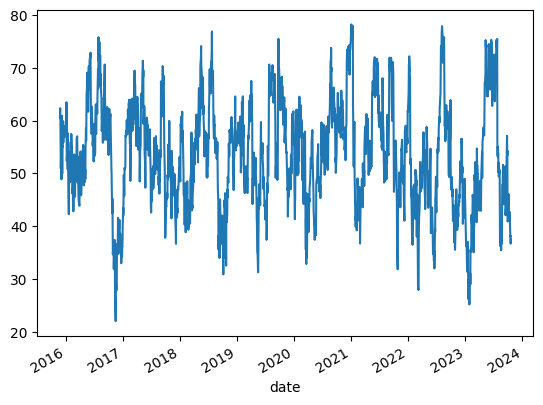

In [12]:
df.xs("ASIANPAINT.NS", level=1)["rsi"].plot()